## Import Library

In [35]:
# IMPORT LIBRARIES
import os
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import joblib


# Machine Learning
from sklearn.svm import SVC

from sklearn.model_selection import train_test_split

from sklearn.model_selection import (
    LeaveOneOut,
    cross_val_predict,
    GridSearchCV,
    train_test_split
)

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# HOG Feature Extraction
from skimage.feature import hog

print("All Libraries Successfully Imported")

All Libraries Successfully Imported


## Setup & Configuration

In [36]:
# CONFIGURATION

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Dataset Path
DATASET_PATH = './Data Sheet/emnist-balanced-test.csv'

# Number of samples used
SAMPLE_TOTAL = 940

# HOG Parameters
HOG_PARAMS = {
    'orientations': 9,
    'pixels_per_cell': (8,8),
    'cells_per_block': (2,2)
}

# Default SVM Parameters
SVM_PARAMS = {
    'kernel': 'rbf',
    'C': 10,
    'gamma': 'scale'
}

print("Configuration Loaded")
print("Dataset Path :", DATASET_PATH)
print("Sample Total :", SAMPLE_TOTAL)
print("HOG Params :", HOG_PARAMS)
print("SVM Params :", SVM_PARAMS)

Configuration Loaded
Dataset Path : ./Data Sheet/emnist-balanced-test.csv
Sample Total : 940
HOG Params : {'orientations': 9, 'pixels_per_cell': (8, 8), 'cells_per_block': (2, 2)}
SVM Params : {'kernel': 'rbf', 'C': 10, 'gamma': 'scale'}


## Cek Dataset

In [20]:
# LOAD DATASET

print("Checking Dataset File...")

print("File Exists :", os.path.exists(DATASET_PATH))

# Load CSV
df = pd.read_csv(DATASET_PATH,header=None)

print("\nDataset Successfully Loaded")

print("\nDataset Shape :")
print(df.shape)

print("\nFirst 5 Rows :")
display(df.head())

Checking Dataset File...
File Exists : True

Dataset Successfully Loaded

Dataset Shape :
(18800, 785)

First 5 Rows :


,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,41,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,39,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,26,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,44,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Dataset Preview

In [37]:
# DATASET INFORMATION

labels = df.iloc[:,0]

print("Unique Labels :")
print(sorted(labels.unique()))

print("\nTotal Classes :")
print(len(labels.unique()))

print("\nClass Distribution :")
print(labels.value_counts().sort_index())

Unique Labels :
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46]

Total Classes :
47

Class Distribution :
0
0     400
1     400
2     400
3     400
4     400
5     400
6     400
7     400
8     400
9     400
10    400
11    400
12    400
13    400
14    400
15    400
16    400
17    400
18    400
19    400
20    400
21    400
22    400
23    400
24    400
25    400
26    400
27    400
28    400
29    400
30    400
31    400
32    400
33    400
34    400
35    400
36    400
37    400
38    400
39    400
40    400
41    400
42    400
43    400
44    400
45    400
46    400
Name: count, dtype: int64


## BALANCED SAMPLING

In [38]:
# BALANCED SAMPLING

def pick_balanced_samples(dataframe,total_samples=1000):
    labels = sorted(dataframe.iloc[:,0].unique())
    per_class = total_samples // len(labels)
    sampled_parts = []

    for lbl in labels:
        subset = dataframe[dataframe.iloc[:,0] == lbl]
        sampled = subset.sample(per_class,random_state=RANDOM_SEED)
        sampled_parts.append(sampled)

    sampled_df = pd.concat(sampled_parts)
    sampled_df = sampled_df.sample(frac=1,random_state=RANDOM_SEED).reset_index(drop=True)
    return sampled_df

# Run balanced sampling
df_sampled = pick_balanced_samples(df,total_samples=SAMPLE_TOTAL)

print("Balanced Dataset Shape :")
print(df_sampled.shape)

Balanced Dataset Shape :
(940, 785)


## VISUALIZE CLASS DISTRIBUTION

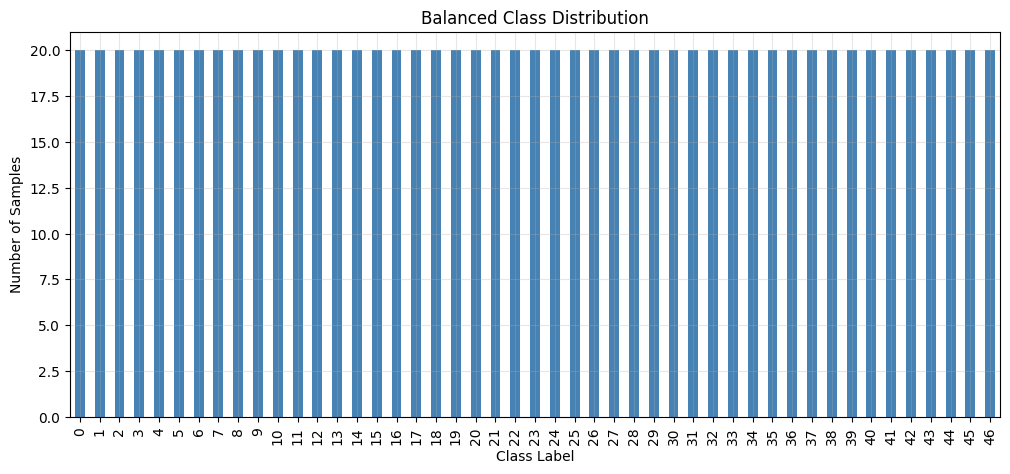

In [39]:
# VISUALIZE CLASS DISTRIBUTION

sample_labels = df_sampled.iloc[:,0]

plt.figure(figsize=(12,5))

sample_labels.value_counts().sort_index().plot(kind='bar',color='steelblue')

plt.title("Balanced Class Distribution")
plt.xlabel("Class Label")
plt.ylabel("Number of Samples")

plt.grid(alpha=0.3)

plt.show()

## Preprocesing Image

Images Shape :
(940, 28, 28)

Labels Shape :
(940,)


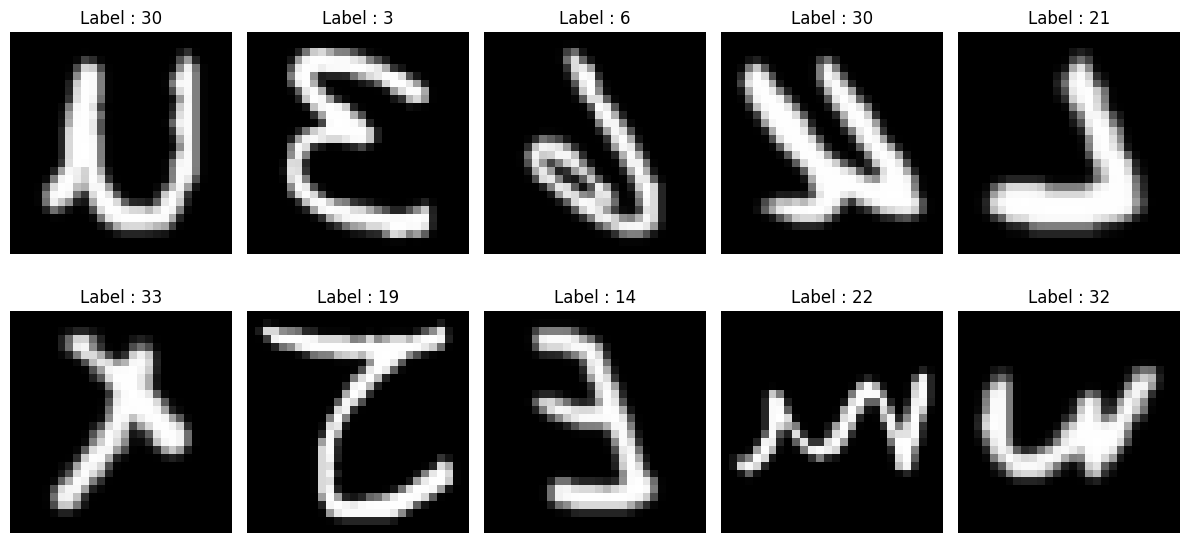

In [24]:
# IMAGE PREPROCESSING

def to_image(row):

    image = np.array(row).reshape(28,28)
    # Fix EMNIST orientation
    image = np.transpose(image)
    image = np.fliplr(image)
    return image

# Convert all rows into images
X_images = np.array([
    to_image(row)
    for row in df_sampled.iloc[:,1:].values])

# Labels
y = df_sampled.iloc[:,0].values

print("Images Shape :")
print(X_images.shape)

print("\nLabels Shape :")
print(y.shape)

# VISUALIZE SAMPLE IMAGES

plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_images[i],cmap='gray')
    plt.title(f"Label : {y[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## HOG FEATURE EXTRACTION

In [25]:
# HOG FEATURE EXTRACTION

def extract_hog_features(images):

    features_list = []
    for image in images:

        features = hog(
            image,
            orientations=HOG_PARAMS['orientations'],
            pixels_per_cell=HOG_PARAMS['pixels_per_cell'],
            cells_per_block=HOG_PARAMS['cells_per_block'],
            block_norm='L2-Hys',
            feature_vector=True
        )

        features_list.append(features)

    return np.array(features_list)

# Extract HOG features
X_hog = extract_hog_features(X_images)

print("HOG Feature Shape :")
print(X_hog.shape)

HOG Feature Shape :
(940, 144)


## HOG VISUALIZATION

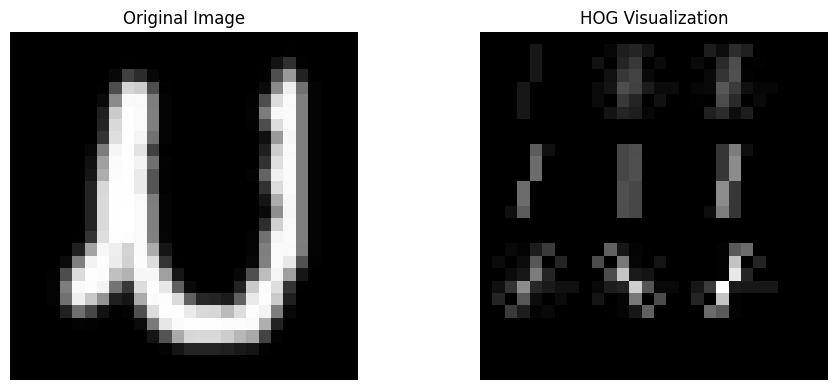

Feature Scaling Completed
Scaled Feature Shape :
(940, 144)


In [26]:
# HOG VISUALIZATION

sample_image = X_images[0]

features, hog_image = hog(
    sample_image,
    orientations=HOG_PARAMS['orientations'],
    pixels_per_cell=HOG_PARAMS['pixels_per_cell'],
    cells_per_block=HOG_PARAMS['cells_per_block'],
    visualize=True
)

plt.figure(figsize=(10,4))

# Original Image
plt.subplot(1,2,1)

plt.imshow(sample_image,cmap='gray')
plt.title("Original Image")
plt.axis('off')

# HOG Image
plt.subplot(1,2,2)
plt.imshow(hog_image,cmap='gray')
plt.title("HOG Visualization")
plt.axis('off')
plt.tight_layout()
plt.show()

# FEATURE NORMALIZATION
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_hog)

print("Feature Scaling Completed")

print("Scaled Feature Shape :")
print(X_scaled.shape)

## SVM PARAMETER TUNING

In [40]:
# SVM PARAMETER TUNING

from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
import time

print("Starting GridSearchCV...")

param_grid = {

    'C': [1,10],

    'kernel': ['linear','rbf'],

    'gamma': ['scale','auto']

}

grid_search = GridSearchCV(estimator=SVC(),param_grid=param_grid,
    cv=5,scoring='accuracy',

    # PERBAIKAN
    # sebelumnya n_jobs=4
    # bikin error BrokenProcessPool di Windows
    n_jobs=1,verbose=1)

start_time = time.time()

grid_search.fit(X_scaled,y)
end_time = time.time()

print("\n===================================")
print("GridSearch Completed")

print("\nBest Parameters:")
print(grid_search.best_params_)

print("\nBest Accuracy:")
print(grid_search.best_score_)

print("\nExecution Time:")
print(round((end_time-start_time)/60,2),"minutes")

# simpan parameter terbaik
BEST_SVM = grid_search.best_params_

Starting GridSearchCV...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

GridSearch Completed

Best Parameters:
{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

Best Accuracy:
0.6170212765957448

Execution Time:
0.06 minutes


## USE BEST PARAMETERS

In [28]:
# USE BEST PARAMETERS
BEST_SVM_PARAMS = grid_search.best_params_

print("Best Parameters Loaded :")
print(BEST_SVM_PARAMS)

svm_model = SVC(**BEST_SVM_PARAMS)

Best Parameters Loaded :
{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


## LOOCV EVALUATION

In [29]:
# LOOCV EVALUATION

loo = LeaveOneOut()

print("Running LOOCV...")
print("This process may take several minutes...")

start_time = time.time()

y_pred = cross_val_predict(
    svm_model,
    X_scaled,y,
    cv=loo,
    n_jobs=1)

end_time = time.time()
print("\nLOOCV Completed")

print(
    "Execution Time :",
    (end_time - start_time)/60,
    "minutes")

Running LOOCV...
This process may take several minutes...

LOOCV Completed
Execution Time : 1.4449073314666747 minutes


## EVALUATION METRICS

In [30]:
# EVALUATION METRICS

accuracy = accuracy_score(y,y_pred)
precision = precision_score(y,y_pred,average='weighted')

recall = recall_score(y,y_pred,average='weighted')
f1 = f1_score(y,y_pred,average='weighted')

print("="*50)
print("Accuracy :",accuracy)
print("Precision :",precision)
print("Recall :",recall)
print("F1 Score :",f1)
print("="*50)

# CLASSIFICATION REPORT
report = classification_report(y,y_pred)
print(report)

Accuracy : 0.6127659574468085
Precision : 0.6218823960267856
Recall : 0.6127659574468085
F1 Score : 0.6133160409860425
              precision    recall  f1-score   support

           0       0.46      0.55      0.50        20
           1       0.32      0.40      0.36        20
           2       0.78      0.70      0.74        20
           3       0.67      0.50      0.57        20
           4       0.78      0.70      0.74        20
           5       0.63      0.60      0.62        20
           6       0.71      0.75      0.73        20
           7       0.83      0.75      0.79        20
           8       0.72      0.65      0.68        20
           9       0.70      0.70      0.70        20
          10       0.67      0.70      0.68        20
          11       0.43      0.45      0.44        20
          12       0.76      0.65      0.70        20
          13       0.56      0.75      0.64        20
          14       0.48      0.50      0.49        20
          15    

## CONFUSION MATRIX

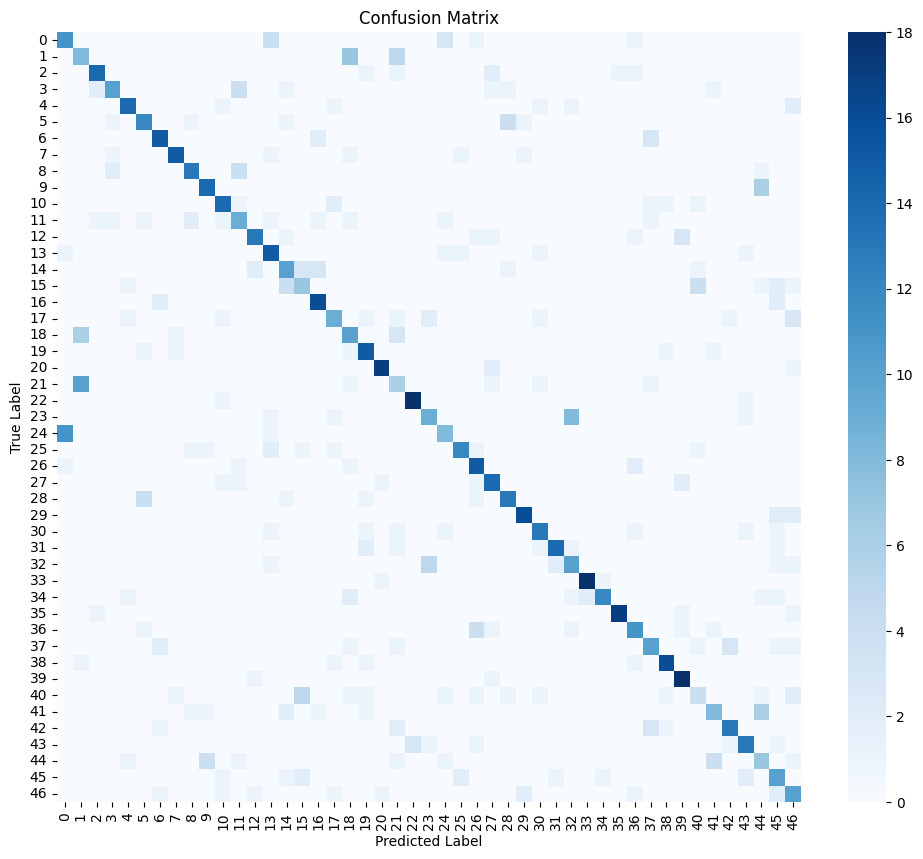

In [41]:
# CONFUSION MATRIX
cm = confusion_matrix(y,y_pred)
plt.figure(figsize=(12,10))

sns.heatmap(cm,cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## VISUALIZATION OF METRICS

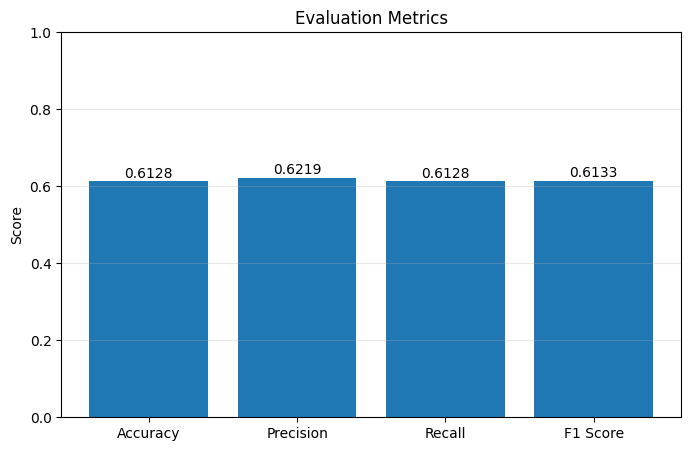

In [42]:
# VISUALIZATION OF METRICS

metric_names = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1 Score'
]

metric_values = [
    accuracy,
    precision,
    recall,
    f1
]

plt.figure(figsize=(8,5))

bars = plt.bar(
    metric_names,
    metric_values
)

plt.ylim(0,1)
plt.title("Evaluation Metrics")
plt.ylabel("Score")

for i, v in enumerate(metric_values):
    plt.text(
        i,
        v + 0.01,
        f"{v:.4f}",
        ha='center'
    )

plt.grid(axis='y', alpha=0.3)
plt.show()

## Train Test Evaluation

80:20 TRAIN TEST EVALUATION
Train Shape : (752, 144)
Test Shape  : (188, 144)


,Dataset,Accuracy,Precision,Recall,F1 Score
0,Train 80%,1.000000,1.000000,1.000000,1.000000
1,Test 20%,0.606383,0.654154,0.606383,0.591859



Train Accuracy : 1.0
Test Accuracy  : 0.6063829787234043


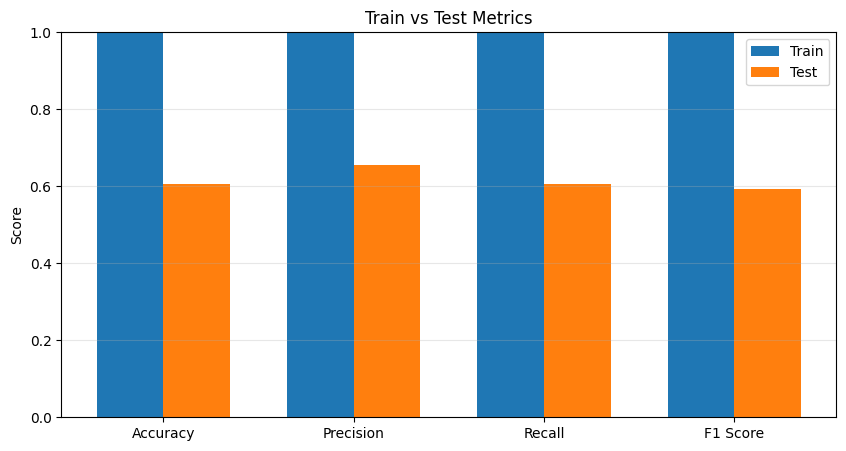

In [43]:
# 80:20 TRAIN TEST EVALUATION

print("="*60)
print("80:20 TRAIN TEST EVALUATION")
print("="*60)

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(

    X_hog,
    y,

    test_size=0.20,

    random_state=RANDOM_SEED,

    stratify=y
)

print("Train Shape :", X_train.shape)
print("Test Shape  :", X_test.shape)

# Feature Scaling
scaler_split = StandardScaler()
X_train_scaled = scaler_split.fit_transform(X_train)
X_test_scaled = scaler_split.transform(X_test)

# Train SVM
svm_split = SVC(**BEST_SVM_PARAMS)
svm_split.fit(X_train_scaled, y_train)

# Prediction
y_train_pred = svm_split.predict(X_train_scaled)

y_test_pred = svm_split.predict(X_test_scaled)

# TRAIN METRICS
train_accuracy = accuracy_score(y_train,y_train_pred)
train_precision = precision_score(
    y_train,
    y_train_pred,
    average='weighted'
)

train_recall = recall_score(
    y_train,
    y_train_pred,
    average='weighted'
)

train_f1 = f1_score(
    y_train,
    y_train_pred,
    average='weighted'
)

# TEST METRICS

test_accuracy = accuracy_score(y_test,y_test_pred)
test_precision = precision_score(
    y_test,
    y_test_pred,
    average='weighted'
)

test_recall = recall_score(
    y_test,
    y_test_pred,
    average='weighted'
)

test_f1 = f1_score(
    y_test,
    y_test_pred,
    average='weighted'
)

# DISPLAY RESULTS

results_split = pd.DataFrame({
    'Dataset':['Train 80%','Test 20%'],
    'Accuracy':[train_accuracy,test_accuracy],
    'Precision':[train_precision,test_precision],
    'Recall':[train_recall,test_recall],
    'F1 Score':[train_f1,test_f1]
})

display(results_split)
print("\nTrain Accuracy :", train_accuracy)
print("Test Accuracy  :", test_accuracy)

# VISUALIZATION

metric_names = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1 Score'
]

train_values = [
    train_accuracy,
    train_precision,
    train_recall,
    train_f1
]

test_values = [
    test_accuracy,
    test_precision,
    test_recall,
    test_f1
]

x = np.arange(len(metric_names))
width = 0.35
plt.figure(figsize=(10,5))
plt.bar(
    x - width/2,
    train_values,
    width,
    label='Train'
)

plt.bar(
    x + width/2,
    test_values,
    width,
    label='Test'
)

plt.xticks(x, metric_names)
plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Train vs Test Metrics")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

## SAVE MODEL

In [44]:
# Train final model
svm_model.fit(X_scaled,y)

# Save model
joblib.dump(svm_model,'svm_emnist_model.pkl')

# Save scaler
joblib.dump(scaler,'scaler_emnist.pkl')
print("Model Successfully Saved")

# FINAL SUMMARY
print("="*60)
print("FINAL RESULT")
print("="*60)

print("Dataset Used : EMNIST Balanced")

print("Total Samples :", SAMPLE_TOTAL)

print("HOG Parameters :")
print(HOG_PARAMS)

print("\nSVM Parameters :")
print(BEST_SVM_PARAMS)

print("\nFinal Metrics")
print("Accuracy :", round(accuracy,4))
print("Precision :", round(precision,4))
print("Recall :", round(recall,4))
print("F1 Score :", round(f1,4))
print("="*60)

Model Successfully Saved
FINAL RESULT
Dataset Used : EMNIST Balanced
Total Samples : 940
HOG Parameters :
{'orientations': 9, 'pixels_per_cell': (8, 8), 'cells_per_block': (2, 2)}

SVM Parameters :
{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

Final Metrics
Accuracy : 0.6128
Precision : 0.6219
Recall : 0.6128
F1 Score : 0.6133
